In [1]:
# Train volterra forward model

from sparseDPD import Volterra, DataManager

# Train Volterra and NN forward models on simple dataset
simpleDataManager = DataManager(filepath='UCD_datasets/PA_IO.mat', num_training_points=19000, num_validaiton_points=1000, num_test_points=2000)

# Setup a volterra model and a volterra inverse
volterra_forward_model = Volterra(num_nl_orders=5, num_memory_levels=20, dataset=simpleDataManager.training_dataset)

print(f" Volterra NMSE: {volterra_forward_model.calculate_volterra_nmse(simpleDataManager.test_dataset)} dB")

 Volterra NMSE: -41.43748158608608 dB


In [ ]:
# Now train inverse model using PNTDNN_3_layer 
from sparseDPD import PNTDNN_NeuralNetwork

# Using PNTDNN on original simple dataset
PNTDNN_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=20, model_type='OneLayerNetwork', forward_model=False)
train_losses_inv, valid_losses_inv, best_epoch_inv = PNTDNN_inverse_nn.get_best_model(num_epochs=600, training_dataset=simpleDataManager.training_dataset, 
                                                                               validation_dataset=simpleDataManager.validation_dataset, learning_rate=1e-3)

Using cuda device
Epoch  10/600  Loss=8.0546e+00  Valid Loss=3.4354e-01  LR=1.00e-03
Epoch  20/600  Loss=2.3567e+00  Valid Loss=1.1624e-01  LR=1.00e-03
Epoch  30/600  Loss=1.0217e+00  Valid Loss=5.0100e-02  LR=1.00e-03
Epoch  40/600  Loss=5.6208e-01  Valid Loss=2.6086e-02  LR=1.00e-03
Epoch  50/600  Loss=3.8217e-01  Valid Loss=1.7101e-02  LR=1.00e-03
Epoch  60/600  Loss=2.6315e-01  Valid Loss=1.1546e-02  LR=1.00e-03
Epoch  70/600  Loss=2.2854e-01  Valid Loss=9.6092e-03  LR=1.00e-03
Epoch  80/600  Loss=2.0439e-01  Valid Loss=8.4002e-03  LR=1.00e-03
Epoch  90/600  Loss=1.8366e-01  Valid Loss=7.3326e-03  LR=1.00e-03
Epoch 100/600  Loss=1.6631e-01  Valid Loss=6.6213e-03  LR=1.00e-03
Epoch 110/600  Loss=1.4672e-01  Valid Loss=5.6180e-03  LR=1.00e-03
Epoch 120/600  Loss=1.2916e-01  Valid Loss=5.5732e-03  LR=1.00e-03
Epoch 130/600  Loss=8.4411e-02  Valid Loss=4.0419e-03  LR=5.00e-04
Epoch 140/600  Loss=8.2809e-02  Valid Loss=4.0104e-03  LR=5.00e-04
Epoch 150/600  Loss=7.3503e-02  Valid Loss=3

Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.Volterra.Volterra'>


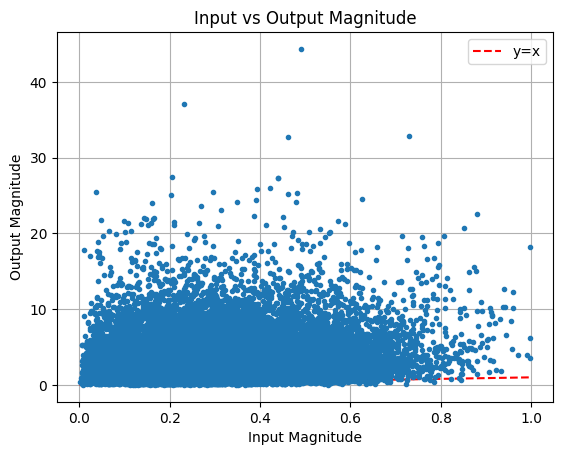

In [ ]:
# Create full datapath with volterra forward and PNTDNN inverse
from sparseDPD import Datapath
datapath = Datapath(forward_model=volterra_forward_model, inverse_model=PNTDNN_inverse_nn)

data = datapath.process(input_signal=simpleDataManager.test_dataset.input_data)
datapath.plot_signals(data)

Your inverse model is type <class 'sparseDPD.Volterra.Volterra'> and your forward model is type <class 'sparseDPD.Volterra.Volterra'>


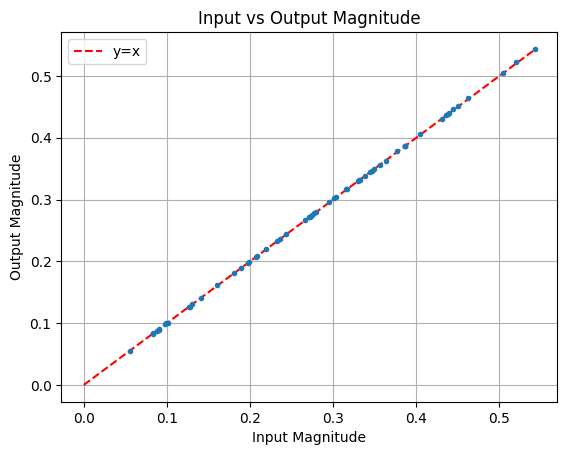

In [ ]:
# test does it work with volterra inverse also
from sparseDPD import Datapath
volterra_inverse_model = Volterra(num_nl_orders=5, num_memory_levels=20, dataset=simpleDataManager.training_dataset, forward=False)
datapath = Datapath(forward_model=volterra_forward_model, inverse_model=volterra_inverse_model)

data = datapath.process(input_signal=simpleDataManager.test_dataset.input_data[:100])
datapath.plot_signals(data)

In [8]:
# Diagnostic: Check individual model performance
import numpy as np

print("=== Individual Model Performance ===")
print(f"Forward model NMSE: {volterra_forward_model.calculate_volterra_nmse(simpleDataManager.test_dataset)} dB")

# Check inverse model by predicting input from output
inverse_predicted_input = volterra_inverse_model.build_y(simpleDataManager.test_dataset.output_data)
actual_input_trimmed = simpleDataManager.test_dataset.input_data[volterra_inverse_model.num_memory_levels:]
min_len = min(len(inverse_predicted_input), len(actual_input_trimmed))
inverse_nmse = 10 * np.log10(np.mean(np.abs(inverse_predicted_input[:min_len] - actual_input_trimmed[:min_len])**2) / np.mean(np.abs(actual_input_trimmed[:min_len])**2))
print(f"Inverse model NMSE: {inverse_nmse:.2f} dB")

# Check signal lengths in the cascade
print("\n=== Cascade Signal Lengths ===")
test_input = simpleDataManager.test_dataset.input_data[:500]
print(f"Original input length: {len(test_input)}")
pre_dist = volterra_inverse_model.build_y(test_input)
print(f"After inverse model: {len(pre_dist)} (lost {len(test_input) - len(pre_dist)} samples)")
final_output = volterra_forward_model.build_y(pre_dist)
print(f"After forward model: {len(final_output)} (lost {len(pre_dist) - len(final_output)} more samples)")
print(f"Total samples lost: {len(test_input) - len(final_output)}")

=== Individual Model Performance ===
Forward model NMSE: -41.43748158608608 dB
Inverse model NMSE: -41.44 dB

=== Cascade Signal Lengths ===
Original input length: 500
After inverse model: 480 (lost 20 samples)
After forward model: 460 (lost 20 more samples)
Total samples lost: 40



=== Testing Cascade Manually ===
Manual cascade NMSE: 12.30 dB


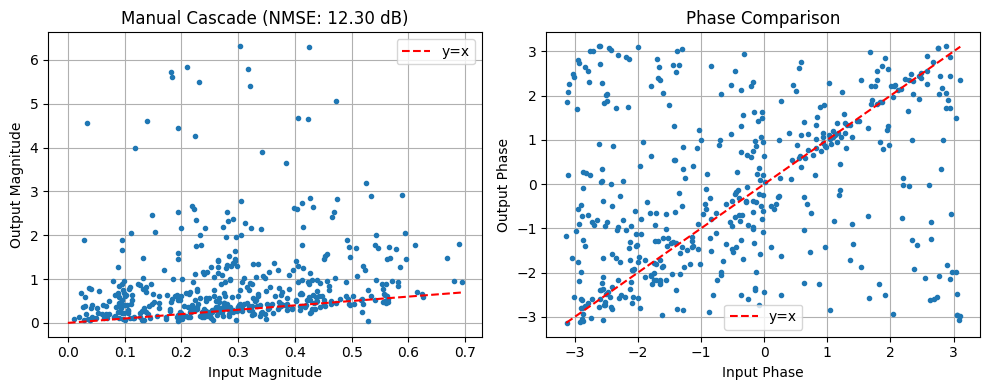

In [9]:
# Check cascade manually with correct alignment
print("\n=== Testing Cascade Manually ===")
test_input = simpleDataManager.test_dataset.input_data[:500]

# Manual cascade
pre_dist = volterra_inverse_model.build_y(test_input)
final_output = volterra_forward_model.build_y(pre_dist)

# Properly align the input signal
# After inverse: output[0] corresponds to input[20]
# After forward: output[0] corresponds to input[40]
aligned_input = test_input[40:40+len(final_output)]

# Calculate NMSE
nmse_manual = 10 * np.log10(np.mean(np.abs(final_output - aligned_input)**2) / np.mean(np.abs(aligned_input)**2))
print(f"Manual cascade NMSE: {nmse_manual:.2f} dB")

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(np.abs(aligned_input), np.abs(final_output), '.')
plt.plot([0, np.max(np.abs(aligned_input))], [0, np.max(np.abs(aligned_input))], 'r--', label='y=x')
plt.xlabel('Input Magnitude')
plt.ylabel('Output Magnitude')
plt.title(f'Manual Cascade (NMSE: {nmse_manual:.2f} dB)')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(np.angle(aligned_input), np.angle(final_output), '.')
plt.plot([np.min(np.angle(aligned_input)), np.max(np.angle(aligned_input))], 
         [np.min(np.angle(aligned_input)), np.max(np.angle(aligned_input))], 'r--', label='y=x')
plt.xlabel('Input Phase')
plt.ylabel('Output Phase')
plt.title('Phase Comparison')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


=== Testing CORRECT Cascade Directions ===

1. Forward then Inverse (Input → PA → DPD → Output):
   NMSE: -45.71 dB

2. Inverse then Forward (Output → DPD → PA → Output):
   NMSE: 10.07 dB


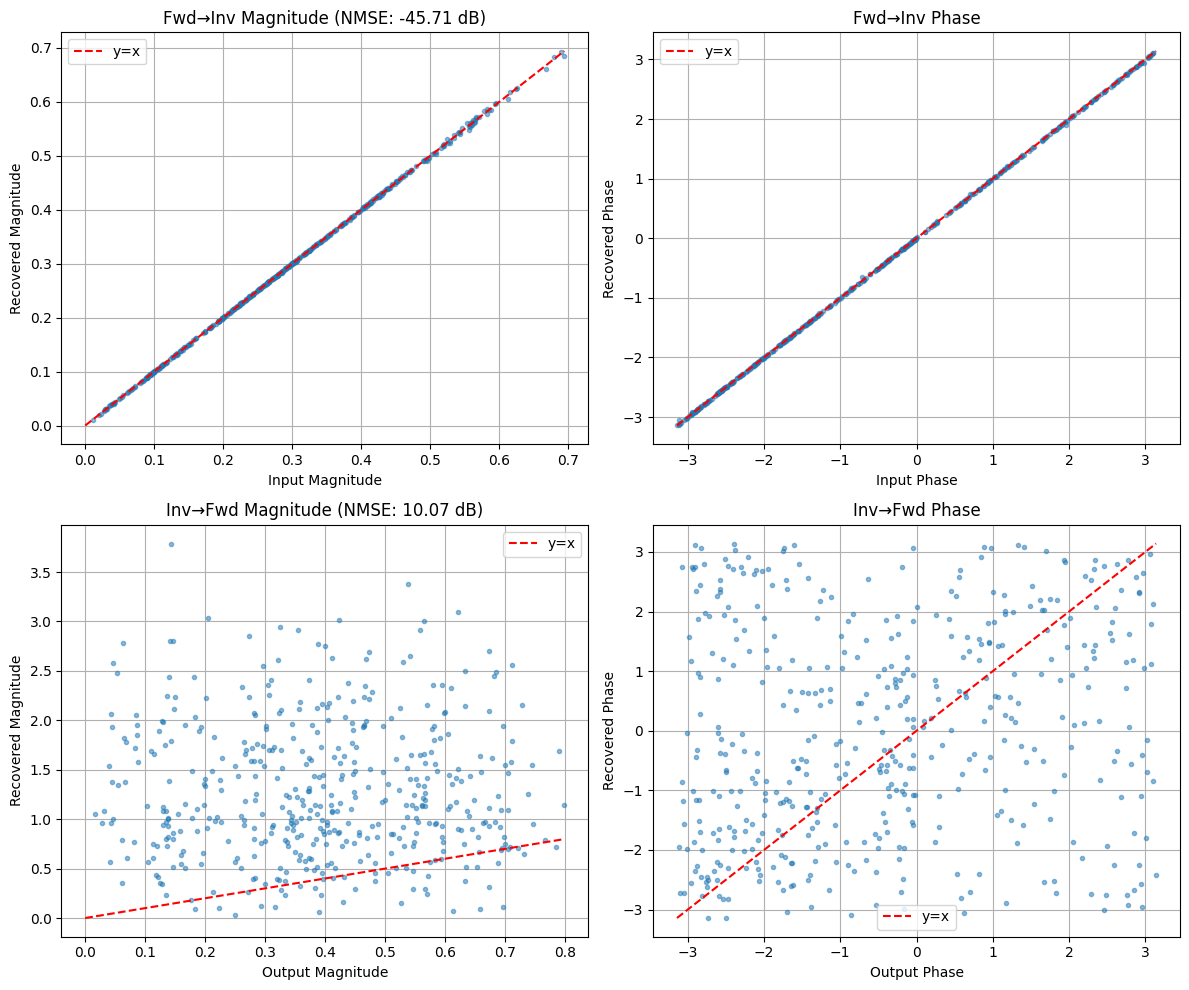

In [10]:
# Test CORRECT cascade directions
print("\n=== Testing CORRECT Cascade Directions ===")

# Option 1: Input → Forward → Inverse → Should recover Input
print("\n1. Forward then Inverse (Input → PA → DPD → Output):")
test_input = simpleDataManager.test_dataset.input_data[:500]
pa_output = volterra_forward_model.build_y(test_input)
recovered_input = volterra_inverse_model.build_y(pa_output)
aligned_input = test_input[40:40+len(recovered_input)]
nmse_fwd_inv = 10 * np.log10(np.mean(np.abs(recovered_input - aligned_input)**2) / np.mean(np.abs(aligned_input)**2))
print(f"   NMSE: {nmse_fwd_inv:.2f} dB")

# Option 2: Output → Inverse → Forward → Should recover Output
print("\n2. Inverse then Forward (Output → DPD → PA → Output):")
test_output = simpleDataManager.test_dataset.output_data[:500]
dpd_signal = volterra_inverse_model.build_y(test_output) 
final_output = volterra_forward_model.build_y(dpd_signal)
aligned_output = test_output[40:40+len(final_output)]
nmse_inv_fwd = 10 * np.log10(np.mean(np.abs(final_output - aligned_output)**2) / np.mean(np.abs(aligned_output)**2))
print(f"   NMSE: {nmse_inv_fwd:.2f} dB")

# Plot both
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Forward then Inverse - Magnitude
axes[0, 0].plot(np.abs(aligned_input), np.abs(recovered_input), '.', alpha=0.5)
axes[0, 0].plot([0, np.max(np.abs(aligned_input))], [0, np.max(np.abs(aligned_input))], 'r--', label='y=x')
axes[0, 0].set_xlabel('Input Magnitude')
axes[0, 0].set_ylabel('Recovered Magnitude')
axes[0, 0].set_title(f'Fwd→Inv Magnitude (NMSE: {nmse_fwd_inv:.2f} dB)')
axes[0, 0].legend()
axes[0, 0].grid()

# Forward then Inverse - Phase
axes[0, 1].plot(np.angle(aligned_input), np.angle(recovered_input), '.', alpha=0.5)
lim = np.pi
axes[0, 1].plot([-lim, lim], [-lim, lim], 'r--', label='y=x')
axes[0, 1].set_xlabel('Input Phase')
axes[0, 1].set_ylabel('Recovered Phase')
axes[0, 1].set_title(f'Fwd→Inv Phase')
axes[0, 1].legend()
axes[0, 1].grid()

# Inverse then Forward - Magnitude
axes[1, 0].plot(np.abs(aligned_output), np.abs(final_output), '.', alpha=0.5)
axes[1, 0].plot([0, np.max(np.abs(aligned_output))], [0, np.max(np.abs(aligned_output))], 'r--', label='y=x')
axes[1, 0].set_xlabel('Output Magnitude')
axes[1, 0].set_ylabel('Recovered Magnitude')
axes[1, 0].set_title(f'Inv→Fwd Magnitude (NMSE: {nmse_inv_fwd:.2f} dB)')
axes[1, 0].legend()
axes[1, 0].grid()

# Inverse then Forward - Phase
axes[1, 1].plot(np.angle(aligned_output), np.angle(final_output), '.', alpha=0.5)
axes[1, 1].plot([-lim, lim], [-lim, lim], 'r--', label='y=x')
axes[1, 1].set_xlabel('Output Phase')
axes[1, 1].set_ylabel('Recovered Phase')
axes[1, 1].set_title(f'Inv→Fwd Phase')
axes[1, 1].legend()
axes[1, 1].grid()

plt.tight_layout()
plt.show()

In [11]:
# Check statistical properties of signals
print("\n=== Signal Statistics ===")
print("\nOriginal PA Input:")
print(f"  Mean magnitude: {np.mean(np.abs(simpleDataManager.test_dataset.input_data)):.4f}")
print(f"  Std magnitude:  {np.std(np.abs(simpleDataManager.test_dataset.input_data)):.4f}")
print(f"  Max magnitude:  {np.max(np.abs(simpleDataManager.test_dataset.input_data)):.4f}")

print("\nPA Output:")
print(f"  Mean magnitude: {np.mean(np.abs(simpleDataManager.test_dataset.output_data)):.4f}")
print(f"  Std magnitude:  {np.std(np.abs(simpleDataManager.test_dataset.output_data)):.4f}")
print(f"  Max magnitude:  {np.max(np.abs(simpleDataManager.test_dataset.output_data)):.4f}")

test_output = simpleDataManager.test_dataset.output_data[:500]
dpd_signal = volterra_inverse_model.build_y(test_output)
print("\nInverse Model Output (from PA Output):")
print(f"  Mean magnitude: {np.mean(np.abs(dpd_signal)):.4f}")
print(f"  Std magnitude:  {np.std(np.abs(dpd_signal)):.4f}")
print(f"  Max magnitude:  {np.max(np.abs(dpd_signal)):.4f}")

# Check AM/AM and AM/PM characteristics
print("\n=== Checking Forward Model Invertibility ===")
# For a truly invertible model, applying F then F_inv should give identity
# AND applying F_inv then F should also give identity

# We already know F→F_inv works well (-45.71 dB)
# And F_inv→F doesn't work well (10.07 dB)

# This suggests the Volterra inverse is not composition-commutative with forward
print("Forward→Inverse works: -45.71 dB (✓ Good!)")
print("Inverse→Forward fails: 10.07 dB (✗ Poor!)")
print("\nConclusion: The Volterra inverse approximates a LEFT inverse (F_inv ∘ F ≈ I)")
print("            but not a RIGHT inverse (F ∘ F_inv ≠ I)")


=== Signal Statistics ===

Original PA Input:
  Mean magnitude: 0.2961
  Std magnitude:  0.1551
  Max magnitude:  0.9984

PA Output:
  Mean magnitude: 0.3969
  Std magnitude:  0.1845
  Max magnitude:  1.0000

Inverse Model Output (from PA Output):
  Mean magnitude: 0.2940
  Std magnitude:  0.1508
  Max magnitude:  0.6920

=== Checking Forward Model Invertibility ===
Forward→Inverse works: -45.71 dB (✓ Good!)
Inverse→Forward fails: 10.07 dB (✗ Poor!)

Conclusion: The Volterra inverse approximates a LEFT inverse (F_inv ∘ F ≈ I)
            but not a RIGHT inverse (F ∘ F_inv ≠ I)
